# 9. Goodness of fit: chi2 binned e dissimilaridade ponto-a-ponto

**Objetivos:** depois de um ajuste de amplitude, quantificar quão bem o modelo
descreve os dados com dois testes independentes: o chi2 binned de Pearson
(1D e no plano de Dalitz) e o teste unbinned de dissimilaridade ponto-a-ponto
(*point-to-point dissimilarity*, PPD). Ambos seguem M. Williams, "How good are
your fits? Unbinned multivariate goodness-of-fit tests in high energy physics"
(arXiv:1006.3019) — a mesma referência que a literatura do Laura++ usa para
GOF em análises de Dalitz. Veja `docs/goodness_of_fit.md` para as fórmulas e
as ressalvas completas.

Execute as células em ordem em um kernel novo. Massas estão em GeV, invariantes
em GeV² e este notebook usa apenas dados simulados, gerados por ele mesmo.


In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Deve preceder qualquer trabalho numérico: amplitudes usam complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, RealImag, Resonance, generate_toy, plot_pulls,
)


## 1. Um ajuste de exemplo

O mesmo modelo/ajuste da lição 2 (\\(\\rho(770)\\) + não ressonante), repetido
aqui para que este notebook seja independente. O tamanho do toy (1500 eventos)
é deliberadamente modesto: o teste PPD abaixo é `O(n²)` no tamanho conjunto
dados+referência, então convém manter os exemplos didáticos pequenos.


In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=100, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

data = generate_toy(
    model, 1500, parameters=truth, seed=2026,
    method="inverse-transform", inverse_resolution=384, include_momenta=False,
)

session = FitSession(model, data)
result = session.fit({"NR.x": 0.35, "NR.y": 0.45}, simplex=True, ncall=5000)
assert result.valid
session.print_result(result)


valid=True  NLL=1854.625573
parameter                           value            error
NR.x                             0.605656        0.0278449
NR.y                              0.31219        0.0260598


{'NR.x': 0.6056557112021285, 'NR.y': 0.3121904619100832}

## 2. Chi2 binned em 1D

`goodness_of_fit_projection` histograma os dados e uma projeção de MC
reponderada pela densidade ajustada (a mesma técnica usada por
`plot_projection`) nos mesmos bins e calcula o chi2 de Pearson entre elas.

**A ressalva dos graus de liberdade:** os parâmetros vieram de um ajuste de
máxima verossimilhança *unbinned*, não de minimizar este chi2 — por isso o
número exato de graus de liberdade não é conhecido. Só se sabe o limite

```text
chi2(dof = n_bins - n_free_parameters - 1) <= chi2 <= chi2(dof = n_bins - 1)
```

e é exatamente isso que `BinnedChi2Result` reporta: `dof_min`/`dof_max` e os
p-valores correspondentes `p_value_min`/`p_value_max`, em vez de um único par
(potencialmente errado). `n_free_parameters` default já conta só os
`Parameter`s que estão flutuando (aqui, `NR.x` e `NR.y`).


chi2=34.54  n_bins=30  n_free_parameters=2
dof=[27, 29]  p-value=[0.151, 0.22]


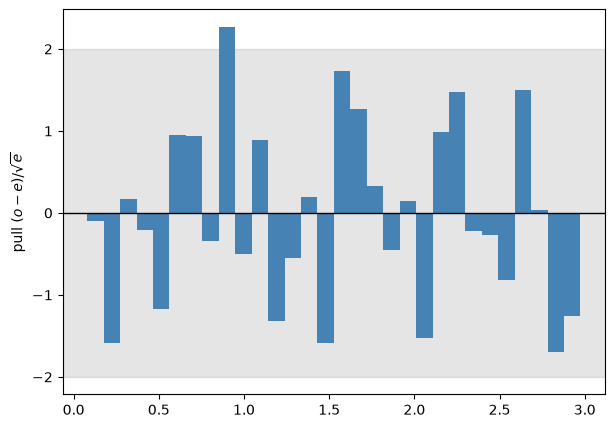

In [3]:
gof_1d = session.goodness_of_fit_projection(result, "s12", bins=30)
print(
    f"chi2={gof_1d.chi2:.2f}  n_bins={gof_1d.n_bins}  "
    f"n_free_parameters={gof_1d.n_free_parameters}\n"
    f"dof=[{gof_1d.dof_min}, {gof_1d.dof_max}]  "
    f"p-value=[{gof_1d.p_value_min:.3g}, {gof_1d.p_value_max:.3g}]"
)
plot_pulls(gof_1d)
plt.show()


## 3. Chi2 binned no plano de Dalitz (2D)

`goodness_of_fit_chi2` faz o mesmo em duas dimensões, com `np.histogram2d`.
`plot_pulls` detecta automaticamente que o resultado é 2D e desenha um mapa
de calor divergente centrado em zero em vez do gráfico de barras 1D.
`square_dalitz=True` (não usado aqui) trocaria as coordenadas para
\\((m', \\theta')\\) — veja `docs/square_dalitz.md` e `docs/goodness_of_fit.md`.


chi2=103.31  n_bins=156  p-value=[0.999, 1]


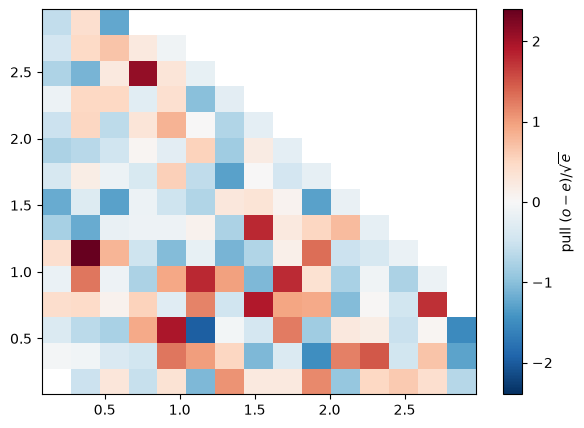

In [4]:
gof_2d = session.goodness_of_fit_chi2(result, "s12", "s13", bins=15)
print(
    f"chi2={gof_2d.chi2:.2f}  n_bins={gof_2d.n_bins}  "
    f"p-value=[{gof_2d.p_value_min:.3g}, {gof_2d.p_value_max:.3g}]"
)
plot_pulls(gof_2d)
plt.show()


## 4. Dissimilaridade ponto-a-ponto (PPD)

O teste PPD (Williams, Seção 3.3) evita completamente o problema de escolher
bins. Ele compara os dados diretamente com uma amostra de MC não-ponderada
gerada pela densidade ajustada, através de

```text
T = (1/n_d^2) * soma_{i<j nos dados} psi(x_i, x_j)
    - (1/(n_d*n_mc)) * soma_{i nos dados, j na referência} psi(x_i, x_j)
```

com `psi` um kernel Gaussiano cuja largura local depende da densidade
ajustada (`sigma_bar` é um parâmetro de ajuste, não uma constante física —
veja `docs/goodness_of_fit.md`). Como a distribuição nula de `T` não é
conhecida analiticamente, o p-valor vem de um **teste de permutação**
(embaralhar repetidamente os rótulos dados/referência e comparar).

Este teste é `O(n²)` no tamanho conjunto dados+referência; `max_total_events`
(padrão 5000) levanta um erro claro em vez de tentar alocar um array denso
enorme — por isso o toy desta lição é pequeno.


In [5]:
ppd = session.point_to_point_dissimilarity(result, mc_size=3000, n_permutations=100)
print(ppd)
print(
    "\nUm único p-valor de uma única pseudo-experiência é apenas isso — um único\n"
    "ponto. Perto de 0.05 ele não deve, por si só, decidir se o modelo está\n"
    "certo ou errado; compare com `n_permutations` maior e, se possível, com\n"
    "outros toys (o mesmo princípio do 'closure criterion' em docs/fitting.md)."
)


PointToPointResult(statistic=-5.1884978122300867e-05, p_value=0.03999999910593033, n_permutations=100, sigma_bar=0.01, n_data=1500, n_reference=3000)

Um único p-valor de uma única pseudo-experiência é apenas isso — um único
ponto. Perto de 0.05 ele não deve, por si só, decidir se o modelo está
certo ou errado; compare com `n_permutations` maior e, se possível, com
outros toys (o mesmo princípio do 'closure criterion' em docs/fitting.md).


## 5. Comparando um modelo correto com um modelo errado

Os mesmos dados, mas ajustados com um modelo deliberadamente incompleto (sem o
\\(\\rho(770)\\)) — o mesmo tipo de discrepância que os testes de GOF devem
conseguir rejeitar. Compare os p-valores com os da lição 2.


modelo correto  (com rho): chi2 p-value = (0.15080056742996903, 0.21990875675986069)  PPD p-value = 0.03999999910593033
modelo incompleto (sem rho): chi2 p-value = (8.877509700878342e-117, 2.0981573615267536e-115)  PPD p-value = 0.0


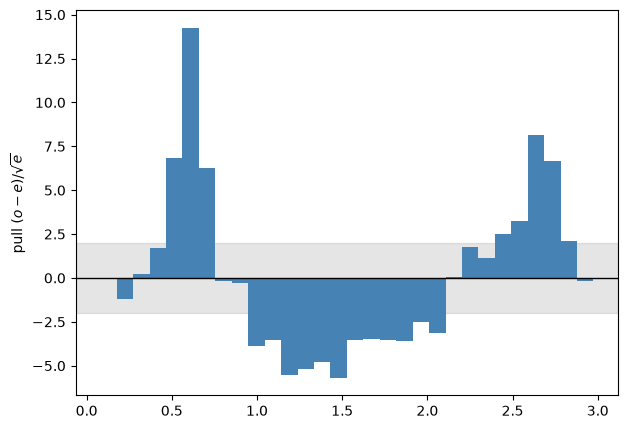

In [6]:
wrong_model = DecayModel(
    channel, [NonResonant(RealImag(x, y), name="NR")],
    normalization_method="square-dalitz", normalization_resolution=100,
    normalization_pair=(0, 1),
)
wrong_session = FitSession(wrong_model, data)
wrong_result = wrong_session.fit({"NR.x": 0.35, "NR.y": 0.45}, simplex=True, ncall=5000)

gof_wrong = wrong_session.goodness_of_fit_projection(wrong_result, "s12", bins=30)
ppd_wrong = wrong_session.point_to_point_dissimilarity(
    wrong_result, mc_size=3000, n_permutations=100,
)

print("modelo correto  (com rho): chi2 p-value =", (gof_1d.p_value_min, gof_1d.p_value_max), " PPD p-value =", ppd.p_value)
print("modelo incompleto (sem rho): chi2 p-value =", (gof_wrong.p_value_min, gof_wrong.p_value_max), " PPD p-value =", ppd_wrong.p_value)
assert gof_wrong.p_value_max < gof_1d.p_value_min

plot_pulls(gof_wrong)
plt.show()


## 6. `CPFitSession`

`CPFitSession` (lição 6) espelha exatamente os três métodos acima, por carga:
`goodness_of_fit_projection`/`goodness_of_fit_chi2` devolvem
`{"plus": ..., "minus": ...}` por padrão (ou um único resultado com
`charge="plus"`/`"minus"`), e `point_to_point_dissimilarity` exige `charge`
explicitamente — o teste de Williams compara uma amostra de dados com uma
amostra de referência de uma única densidade, então uma versão "conjunta"
através das duas cargas não é uma estatística documentada.
Veja `docs/goodness_of_fit.md` (seção "CP fits") e o exemplo real em
[`data_analyses/12_b2kkk_cpvfit.ipynb`](../data_analyses/12_b2kkk_cpvfit.ipynb),
que inclui uma seção completa de GOF, incluindo o PPD em uma subamostra dos
dados (necessário para uma amostra grande, por causa do custo `O(n²)`).


## Resumo e exercícios

1. Aumente `n_permutations` no PPD do modelo correto e veja se o p-valor se
   estabiliza.
2. Diminua o número de bins no chi2 2D até que nenhum bin fique vazio
   (`n_bins` no resultado conta só os bins com contagem esperada positiva).
3. Repita a Seção 5 removendo o componente não-ressonante em vez do
   \\(\\rho(770)\\); compare a sensibilidade dos dois testes a esse tipo
   diferente de discrepância (localizada vs. onipresente no plano de Dalitz).
4. Tente `session.point_to_point_dissimilarity(result, sigma_bar=0.1)` e
   `sigma_bar=0.001`: o `sigma_bar` padrão (0.01) não é sagrado.

Consulte [goodness of fit](../../docs/goodness_of_fit.md) para as fórmulas
completas e mais detalhes.

Retorne ao [guia do curso](TUTORIALS.md).
